In [1]:
# Cross-Validation Theory


In [2]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# Load dataset (regression example - same one used in Week 6)
data = load_diabetes()
X, y = data.data, data.target

# Demonstrate instability: run 10 different random splits, same model
scores = []
for seed in range(10):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )
    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    scores.append(rmse)

scores = np.array(scores)
print("RMSE per random split:", np.round(scores, 2))
print(f"Min: {scores.min():.2f}  Max: {scores.max():.2f}  Range: {scores.max()-scores.min():.2f}")
print(f"Mean: {scores.mean():.2f}  Std: {scores.std():.2f}")


RMSE per random split: [58.13 57.2  57.2  59.03 56.76 59.87 55.61 54.6  56.42 51.94]
Min: 51.94  Max: 59.87  Range: 7.93
Mean: 56.68  Std: 2.15


In [3]:
# K-Fold Cross-Validation

from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = Ridge(alpha=1.0)

# cross_val_score handles the fit/predict/score loop internally
cv_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error')
cv_rmse = -cv_scores  # sklearn returns negative for "higher is better" convention

print("RMSE per fold:", np.round(cv_rmse, 2))
print(f"CV Mean RMSE: {cv_rmse.mean():.2f}  CV Std: {cv_rmse.std():.2f}")


RMSE per fold: [55.47 58.47 60.28 57.98 60.61]
CV Mean RMSE: 58.56  CV Std: 1.85


In [4]:
# Stratified K-Fold (for Classification)

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

data_clf = load_breast_cancer()
Xc, yc = data_clf.data, data_clf.target

print("Class distribution (full data):", np.bincount(yc) / len(yc))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf = LogisticRegression(max_iter=5000)

cv_acc = cross_val_score(clf, Xc, yc, cv=skf, scoring='accuracy')
print("Accuracy per fold:", np.round(cv_acc, 3))
print(f"CV Mean Accuracy: {cv_acc.mean():.3f}  CV Std: {cv_acc.std():.3f}")

# Show that each fold keeps the class ratio roughly constant
for i, (train_idx, test_idx) in enumerate(skf.split(Xc, yc)):
    fold_dist = np.bincount(yc[test_idx]) / len(test_idx)
    print(f"Fold {i} test class distribution: {np.round(fold_dist, 3)}")


Class distribution (full data): [0.37258348 0.62741652]
Accuracy per fold: [0.965 0.921 0.965 0.947 0.973]
CV Mean Accuracy: 0.954  CV Std: 0.019
Fold 0 test class distribution: [0.377 0.623]
Fold 1 test class distribution: [0.377 0.623]
Fold 2 test class distribution: [0.368 0.632]
Fold 3 test class distribution: [0.368 0.632]
Fold 4 test class distribution: [0.372 0.628]


In [1]:
# Apply Cross-Validation to Week 6 Model

In [2]:
# Baseline — Single Train/Test Split

import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

data = load_diabetes()
X, y = data.data, data.target

# --- Week 6 style: single split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

baseline_model = Ridge(alpha=1.0)
baseline_model.fit(X_train, y_train)
preds = baseline_model.predict(X_test)

baseline_rmse = mean_squared_error(y_test, preds) ** 0.5
print(f"Week 6 baseline (single split, random_state=42): RMSE = {baseline_rmse:.2f}")


Week 6 baseline (single split, random_state=42): RMSE = 55.47


In [3]:
# Cross-Validation Evaluation (cv=5)

model = Ridge(alpha=1.0)

kf5 = KFold(n_splits=5, shuffle=True, random_state=42)
cv5_scores = -cross_val_score(model, X, y, cv=kf5, scoring='neg_root_mean_squared_error')

print("RMSE per fold (k=5):", np.round(cv5_scores, 2))
print(f"CV(k=5) Mean RMSE: {cv5_scores.mean():.2f}  Std: {cv5_scores.std():.2f}")


RMSE per fold (k=5): [55.47 58.47 60.28 57.98 60.61]
CV(k=5) Mean RMSE: 58.56  Std: 1.85


In [4]:
# Cross-Validation Evaluation (cv=10)

kf10 = KFold(n_splits=10, shuffle=True, random_state=42)
cv10_scores = -cross_val_score(model, X, y, cv=kf10, scoring='neg_root_mean_squared_error')

print("RMSE per fold (k=10):", np.round(cv10_scores, 2))
print(f"CV(k=10) Mean RMSE: {cv10_scores.mean():.2f}  Std: {cv10_scores.std():.2f}")


RMSE per fold (k=10): [56.79 53.41 53.94 61.24 60.64 59.41 50.08 63.67 60.21 60.59]
CV(k=10) Mean RMSE: 58.00  Std: 4.06


In [5]:
# Direct Comparison: Single Split vs CV

# Instability of single split across different random states
single_split_rmses = []
for seed in range(10):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=seed)
    m = Ridge(alpha=1.0)
    m.fit(Xtr, ytr)
    p = m.predict(Xte)
    single_split_rmses.append(mean_squared_error(yte, p) ** 0.5)
single_split_rmses = np.array(single_split_rmses)

print("=== COMPARISON TABLE ===")
print(f"{'Method':<30}{'Mean RMSE':<12}{'Std':<10}{'Range'}")
print(f"{'Single split (10 seeds)':<30}{single_split_rmses.mean():<12.2f}{single_split_rmses.std():<10.2f}"
      f"{single_split_rmses.max()-single_split_rmses.min():.2f}")
print(f"{'CV k=5':<30}{cv5_scores.mean():<12.2f}{cv5_scores.std():<10.2f}"
      f"{cv5_scores.max()-cv5_scores.min():.2f}")
print(f"{'CV k=10':<30}{cv10_scores.mean():<12.2f}{cv10_scores.std():<10.2f}"
      f"{cv10_scores.max()-cv10_scores.min():.2f}")
print()
print(f"Original Week 6 reported number (single seed=42): {baseline_rmse:.2f}")


=== COMPARISON TABLE ===
Method                        Mean RMSE   Std       Range
Single split (10 seeds)       56.68       2.15      7.93
CV k=5                        58.56       1.85      5.14
CV k=10                       58.00       4.06      13.59

Original Week 6 reported number (single seed=42): 55.47


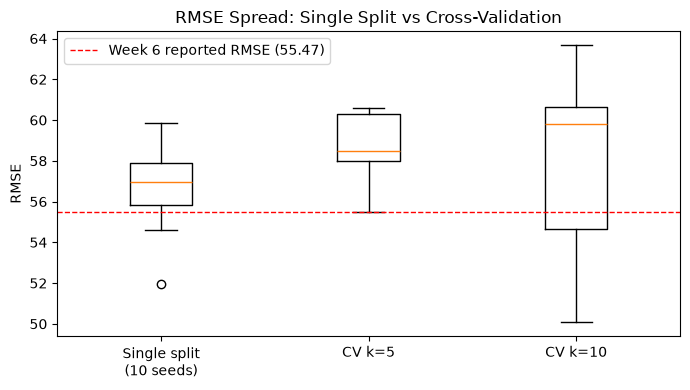

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,4))
ax.boxplot(
    [single_split_rmses, cv5_scores, cv10_scores],
    tick_labels=['Single split\n(10 seeds)', 'CV k=5', 'CV k=10']
)
ax.axhline(baseline_rmse, color='red', linestyle='--', linewidth=1,
           label=f'Week 6 reported RMSE ({baseline_rmse:.2f})')
ax.set_ylabel('RMSE')
ax.set_title('RMSE Spread: Single Split vs Cross-Validation')
ax.legend()
plt.tight_layout()
plt.savefig('rmse_comparison.png', dpi=100)
plt.show()
